# Prerequisites
- Technical
  - Python programming skills
  - Numpy skills
- Theoretical
  - **Information theory**: understanding of concepts such as entropy and information gain.
  - **Basic Statistics**: probability distribution is necessary to calculate class proportions.
  - **Linear algebra**: representing data in matrix form.

# Introduction

## 1. What is a decision tree?

A **decision tree** is a simple model for supervised classification. It helps making decisions by mapping out different choices to their possible outcomes.
It is used for classifying a discrete target feature.

Each internal node performs a boolean test on an input feature. The edges are labeled with the values of that input feature, and each leaf node specifies a value for the target feature.

## 2. What problem do decision trees solve?

They solve classification and regression problems by mapping complex non-linear relationships between input features and target output into an easy-to-interpret flowchart-like structure.

## 3. Real-World applications

- **Fraud detection**: identifiying and preventing fraudulent transactions.
- **Customer segmentation**: classifying customers into groups based on informations about them, which is useful for marketing.
- **Predictive maintenance**: forecasting equipment failure based on sensor data, usage patterns and operating conditions...
- **Medical diagnosis**: predicting the likelihood of a disease for a patient.
- etc...

## 4. When vs When not to use Decision trees
| **Use Decision Trees When** | **Avoid Decision Trees When** |
|------------------------------|-------------------------------|
| You need interpretable, explainable models | You need the highest possible prediction accuracy |
| Data has categorical features and non-linear relationships | Data is high-dimensional with many sparse features |
| You want automatic feature interaction detection | Linear relationships dominate the problem |
| Missing values are present (handles them naturally) | You have very small datasets (prone to overfitting) |
| You need fast predictions in production | Model stability across bootstrap samples is critical |
| Feature importance insights are valuable | You're dealing with unbalanced classes without adjustments |
| The problem involves rule-based decision making | Extrapolation beyond training data is needed |
| You're building ensemble models (Random Forest, XGBoost) | You need smooth decision boundaries |
| Data has mixed types (numerical + categorical) | The signal-to-noise ratio is very low |
| You want a quick baseline model | Computational training time is severely limited (for deep trees) |

# Decision Tree Learning Algorithm

## 1. Algorithm structure: Greedy vs Optimal

- **The Greedy (Myopic) strategy**: because building optimal trees is computationally heavy, while building the decision tree we make the best choice at each step without worrying about future choices.
- **Occam's razor**: this principle states that the simplest, most elegant explanation of a theory or a hypothesis is more likely to be the best, in this case we adopt it because it keeps the DCs smaller and simpler and they're more likely to generalize better than full trees.
- **Overfitting problem**: Growing a full tree is more likely to lead to overfitting, that's why we must consider stopping early to improve performance on test data.

## 2. Algorithm Base Cases

- **Base case 1 -All examples belong to the same class-**: return the class label.
- **Base case 2 -No features left to test-**: return the majority decision for the remaining examples.
- **Base case 3 -No examples left for a feature value-**: return the majority decision from the parent node.

## 3. ID3 (Iterative Dichotomiser 3)

ID3 is a greedy, top-down algorithm used to generate a decision tree from a dataset. It recursively partitions data into subsets using the attribute that maximizes the **Information Gain** at each step.

Assume a set of examples $S$, and a set of attributes ($A$; attribute $a \in A$; value $v \in a$) and a target label $L$ corresponding to the examples in S. The Id3 procedure for building a decision tree is given by the following algorithm:

### <u>**Algorithm 1**: Id3 Procedure</u>
**Initialization**: S, A, L

**Result**: Decision tree
- **if** All examples' labels = $L$ **then**
  - return single node tree with $L$
- **else**
  - $a ←$ attribute that best classifies $S$
  - **for** $v \in a$ **do**
    - Add new tree branch $a = v$
  - **end**
  - $S_v ←$ subset of examples in $S$ such that $a = v$
  - **if** $S_v$ is empty **then**
    - Add leaf node with most common value of label in $S$
  - **else**
    - Add subtree $Id3(S_v, A-\{a\}, L)$
- **end**

## 4. Determining the order of testing features

Since we have adopted the greedy approach, we need a metric to determine which feature is the best choice at each current step. We use Information theory concepts such as **entropy** and **information gain** to measure how much certainty each feature provides.

### Recall: Information Theory concepts
- **Entropy**: a measure of disorder or impurity in a probability distribution, which is a set of examples in our case. Let's denote $p_i$ as the probability of an example belonging to class $c_i$, Entropy for a set of examples $S$ is given as follows:
  - **Distribution with two outcomes** $S = \{c_1, c_2\}$: $$I(\{p_1, p_2\}) = - p_1.log_2(p_1) - p_2.log_2(p_2)$$

  - **Distribution with more than two outcomes** $S = \{c_1,…,c_k\}$: $$I(\{p_1,…,p_k\}) = -\sum_{i=1}^{k}p_i . log_2(p_i)$$
  - If all examples belong to the same label, entropy is 0. If all examples are equally mixed, entropy is 1.

- **Information Gain**: metric that measures the entropy reduction after splitting the data using a feature. In other words, it measures the information content of a feature, meaning how much information we gain from using this feature as a splitting point.

  - Information gain is given by substracting the weighted sum of entropies after split from entropy of the dataset before the split:

$$I_{before} = I(\{p_1,…,p_k\})$$
$$I_{after} = \sum_{{v \in a}}\frac{|S_v|}{|S|}I(S_v)$$
$$Gain(S, A) = I_{before} - I_{after}$$

<center>$S_v$: subset of $S$ where attribute $a$ has value $v$.</center>

### Integrating Information Theory into Id3 Algorithm

To integerate entropy and information gain to our algorithm, the step "$a ←$ attribute that best classifies $S$" is expanded to the following procedure:

<u>**Procedure**: Finding the attribute $a$ that best classifies the current set of examples $S$</u>
- **Calculate System Entropy**: calculate $I(S)$ before split.
- **for** $a$ in $A$ **do**
  - Partition $S$ into subsets $S_v$ based on the values $v$ of $a$.
  - Calculate the weighted entropy of the resulting subsets.
  - Substract it from the system entropy to find **Information Gain** for $a$.
- $a \leftarrow$ attribute with maximum Gain to variable $a$.

## 5. Handling Real-Valued features (continuous values)

Our decision tree so far deals only with discrete values, but when the feature consists of continuous numbers we cannot just create a branch for every unique value, instead we **discretize the feature**:

- **The Binary Split**: we choose a threshold $c$ and create two branches: $feature > c$ and $feature ≤ c$
- **Identifying candidate thresholds**:
  - 1. sort the examples based on the values of the continuous feature.
  - 2. identify "crossover points" where the target label changes from one class to another.
  - 3. The midpoint between these two values is a candidate threshold.
- **Selection**: Calculate **Information Gain** for each candidate threshold and choose the one that maximizes it.

## 6. Overfitting
A decision tree is a flexible model that can grow until it perfectly classifies every training example, including noise. This results in a "full tree" that may generalize poorly to unseen data.

Creating a decision tree that perfectly classifies training data may not lead to the tree that best generalizes to unseen data, this is caused by noise fitted by tree or that the tree is making decisions based on very little data.

- **Occam’s Razor**: This principle suggests that we should prefer the simplest hypothesis (the smallest tree) that is consistent with the data.
- **Stopping Criteria (Pre-pruning)**: Instead of growing a full tree, we can stop the recursion early based on specific limits:
  - **Maximum Depth**: Stop growing the tree once it reaches a certain number of levels.
  - **Node Count**: Stop once the tree has reached a pre-defined number of nodes.
  - **Example Threshold**: Stop if the number of examples at a node falls below a certain threshold.
- **Post-pruning**: This involves growing the full tree first and then removing branches that do not significantly improve performance on a separate validation set.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

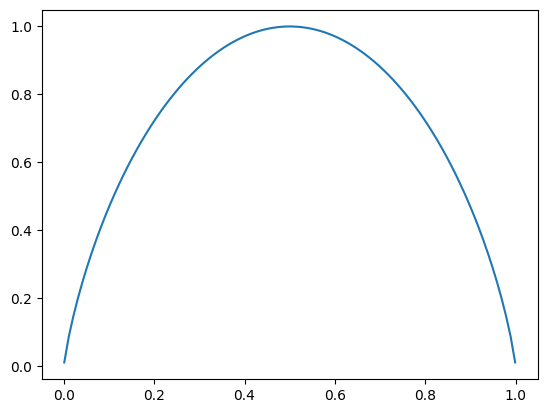

In [ ]:
# Shannon's entropy curve
x = np.linspace(0.001, 0.999, 100)
y = -((1 - x) * (np.log2(1 - x)) + x * (np.log2(x)))

plt.plot(x, y)

In [ ]:
class TreeNode:
  def __init__(self, feature=None, value=None, children=None, gain=None, leaf=False):
    self.feature = feature
    self.value = value
    self.children = children
    self.gain = gain
    self.leaf = leaf

  # def __repr__(self):
  #   if self.leaf:
  #     return f"{self.value}"
  #   if self.value is not None:
  #     return f"Threshold={self.value}"
  #   print(self.feature)
  #   return f"{self.feature}"

  def __repr__(self):
    if self.leaf:
        return f"Leaf: {self.value}"
    if self.value is not None: # This is a continuous split node
        return f"Feature {self.feature} (threshold: {self.value})"
    return f"Feature {self.feature} (discrete)"


class DecisionTree:
  def __init__(self, min_split_samples, max_depth):
    self.X = None
    self.y = None
    self.classes = None
    self.tree_root = None
    self.min_split_samples = min_split_samples
    self.max_depth = max_depth

  def fit(self, X, y):
    self.X = X
    self.y = y
    self.classes = np.unique(y)
    self.tree_root = self.build_tree(X, [_ for _ in range(self.X.shape[1])], y)

  def _is_discrete(self, feature):
    if np.isdtype(feature.dtype, np.str_):
      return True
    return (np.unique(feature.ravel()).shape[0] / feature.shape[0]) <= 0.05

  def _label_prob(self, y, label):
    return y[y == label].shape[0] / y.shape[0]

  def entropy(self, y):
    probs = [self._label_prob(y, label) for label in self.classes]
    return - np.sum(probs * np.log2(probs))

  def information_gain(self, node):
    pass

  def get_best_split_feature(self, X, y):
    pass

  def build_tree(self, X, features, y, parent_node=None):
    if np.unique(y).shape[0] == 1:
      return TreeNode(value=y[0], leaf=True)
    elif len(features) == 0:
      maj_decision = max(
          {label: self._label_prob(y, label) for label in self.classes}
      )
      return TreeNode(value=maj_decision, leaf=True)
    elif X.shape[0] == 0:
      # majority decision at parent node
      pass
    else:
      split_feature = features.pop(0)
      feature_examples = X[:, split_feature]
      if self._is_discrete(feature_examples):
        feature_values = np.unique(feature_examples)
        print({v: X[X[:, split_feature] == v] for v in feature_values})
        return TreeNode(
            feature=split_feature,
            children={
              v: self.build_tree(
                  X[X[:, split_feature] == v],
                  features,
                  y[X[:, split_feature] == v],
                  )
              for v in feature_values
            }
        )
      else:
        threshold = np.round(np.mean(feature_examples), 2)
        return TreeNode(
            feature=split_feature,
            value=threshold,
            children={
                True: self.build_tree(X[X[:, split_feature] >= threshold], features, y[X[:, split_feature] >= threshold]),
                False: self.build_tree(X[X[:, split_feature] < threshold], features, y[X[:, split_feature] < threshold])
            }
        )

  def predict(self, X):
    pass

def pretty_print_tree(node, prefix="", is_last=True, edge_label=""):
  marker = "└── " if is_last else "├── "
  label_str = f"({edge_label}) " if edge_label != "" else ""

  print(prefix + marker + label_str + str(node))
  new_prefix = prefix + ("    " if is_last else "│   ")

  if node.children:
    child_items = list(node.children.items())
    for i, (value, child_node) in enumerate(child_items):
        last_child = (i == len(child_items) - 1)

        friendly_label = str(value)
        if node.value is not None:
            friendly_label = f">= {node.value}" if value else f"< {node.value}"

        pretty_print_tree(child_node, new_prefix, last_child, friendly_label)

In [ ]:
X, y = make_classification(n_samples=150, n_features=5, n_informative=3, random_state=42)
X_train, X_test, y_train, y_test = X[:100], X[100:], y[:100], y[100:]


dt = DecisionTree(4, 2)
dt.fit(X_train, y_train)

pretty_print_tree(dt.tree_root, "")

└── Feature 0 (threshold: -0.36)
    ├── (>= -0.36) Feature 1 (threshold: -0.85)
    │   ├── (>= -0.85) Feature 2 (threshold: 0.75)
    │   │   ├── (>= 0.75) Leaf: 0
    │   │   └── (< 0.75) Feature 3 (threshold: 0.48)
    │   │       ├── (>= 0.48) Feature 4 (threshold: -0.18)
    │   │       │   ├── (>= -0.18) Leaf: 1
    │   │       │   └── (< -0.18) Leaf: 0
    │   │       └── (< 0.48) Leaf: 1
    │   └── (< -0.85) Leaf: 1
    └── (< -0.36) Leaf: 1


In [ ]:
features = np.array(['outlook', 'temp', 'humidity', 'wind'])
X = np.array([
    ['sunny', 'hot', 'high', 'mid'],
    ['sunny', 'hot', 'high', 'strong'],
    ['overcast', 'hot', 'high', 'weak'],
    ['rain', 'mild', 'high', 'weak'],
    ['rain', 'cool', 'normal', 'weak'],
    ['rain', 'cool', 'normal', 'strong'],
    ['overcast', 'cool', 'normal', 'strong'],
    ['sunny', 'mild', 'high', 'weak'],
    ['sunny', 'cool', 'normal', 'normal'],
    ['rain', 'mild', 'normal', 'weak'],
    ['sunny', 'mild', 'normal', 'strong'],
    ['overcast', 'mild', 'high', 'strong'],
    ['overcast', 'hot', 'normal', 'weak'],
    ['rain', 'mild', 'high', 'strong'],
    ])
y = np.array([False, False, True, True, True, False, True, False, True, True, True, True, True, False])

dt = DecisionTree(4, 2)
dt.fit(X, y)

pretty_print_tree(dt.tree_root)

{np.str_('overcast'): array([['overcast', 'hot', 'high', 'weak'],
       ['overcast', 'cool', 'normal', 'strong'],
       ['overcast', 'mild', 'high', 'strong'],
       ['overcast', 'hot', 'normal', 'weak']], dtype='<U8'), np.str_('rain'): array([['rain', 'mild', 'high', 'weak'],
       ['rain', 'cool', 'normal', 'weak'],
       ['rain', 'cool', 'normal', 'strong'],
       ['rain', 'mild', 'normal', 'weak'],
       ['rain', 'mild', 'high', 'strong']], dtype='<U8'), np.str_('sunny'): array([['sunny', 'hot', 'high', 'mid'],
       ['sunny', 'hot', 'high', 'strong'],
       ['sunny', 'mild', 'high', 'weak'],
       ['sunny', 'cool', 'normal', 'normal'],
       ['sunny', 'mild', 'normal', 'strong']], dtype='<U8')}
{np.str_('cool'): array([['rain', 'cool', 'normal', 'weak'],
       ['rain', 'cool', 'normal', 'strong']], dtype='<U8'), np.str_('mild'): array([['rain', 'mild', 'high', 'weak'],
       ['rain', 'mild', 'normal', 'weak'],
       ['rain', 'mild', 'high', 'strong']], dtype='<U8')}
